[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)][def]

[def]: https://colab.research.google.com/github/LEE-Sanghoon/ITE4052/blob/main/Match-Template.ipynb

# 템플릿 매칭 Template Matching

- 입력 영상에서 작은 크기의 부분 영상 위치를 찾아내고 싶은 경우 사용하는 기법
- 템플릿(template)은 찾고자 하는 대상이 되는 작은 크기의 영상
- 템플릿 매칭(template matching)은 템플릿 영상을 입력 영상 전체 영역에 대해 이동하면서 가장 비슷한 위치를 수치적으로 찾아내는 방식
- 특징

  | 장점 | 단점 |
  | --- | --- |
  | 구현이 매우 쉽다 | 크기 변화에 약하다 |
  | 직관적으로 이해하기 좋다 | 회전에 약하다 |
  | 특징 패턴 검출에 적합하다 | 조명 변화에 민감할 수 있다 |
  | 결과를 heatmap 처럼 해석 가능하다 | 템플릿과 검출 대상이 거의 같은 형태여야 한다 |

- 예제
  - Image patch (template)  
    ![](https://docs.opencv.org/4.x/messi_face.jpg)
  - Source image  
    ![](https://github.com/opencv/opencv/blob/b4c5ec4042f097e2a5b386b9d413ec7333d0a184/samples/data/messi5.jpg?raw=true)

In [19]:
!wget https://docs.opencv.org/4.x/messi_face.jpg
!wget https://github.com/opencv/opencv/blob/b4c5ec4042f097e2a5b386b9d413ec7333d0a184/samples/data/messi5.jpg?raw=true -O messi5.jpg

--2026-05-19 11:56:00--  https://docs.opencv.org/4.x/messi_face.jpg
Resolving docs.opencv.org (docs.opencv.org)... 104.26.14.224, 172.67.72.85, 104.26.15.224, ...
Connecting to docs.opencv.org (docs.opencv.org)|104.26.14.224|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1415 (1.4K) [image/jpeg]
Saving to: ‘messi_face.jpg’

messi_face.jpg      100%[===================>]   1.38K  --.-KB/s    in 0s      

2026-05-19 11:56:00 (17.9 MB/s) - ‘messi_face.jpg’ saved [1415/1415]

--2026-05-19 11:56:00--  https://github.com/opencv/opencv/blob/b4c5ec4042f097e2a5b386b9d413ec7333d0a184/samples/data/messi5.jpg?raw=true
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/opencv/opencv/raw/b4c5ec4042f097e2a5b386b9d413ec7333d0a184/samples/data/messi5.jpg [following]
--2026-05-19 11:56:01--  https://github.com/opencv/opencv/raw/b4c

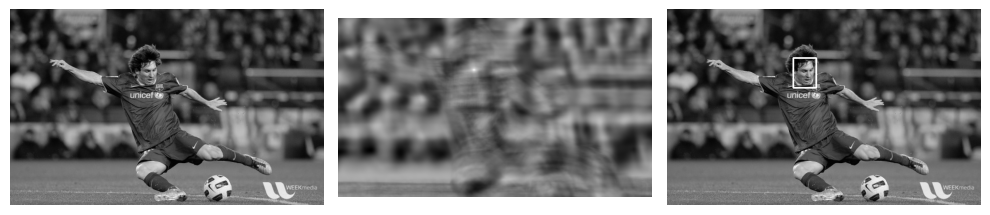

In [20]:
import cv2
import numpy as np

img_file = "messi5.jpg"
img = cv2.imread(img_file,cv2.IMREAD_GRAYSCALE)

template_file = "messi_face.jpg"
template = cv2.imread(template_file,cv2.IMREAD_GRAYSCALE)

result = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

result_img = img.copy()
h, w = template.shape
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)
cv2.rectangle(result_img, top_left, bottom_right, 255, 2)


from matplotlib import pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5))
ax[0].imshow(img, cmap="gray"), ax[0].axis("off")
ax[1].imshow(result, cmap="gray"), ax[1].axis("off")
ax[2].imshow(result_img, cmap="gray"), ax[2].axis("off")

plt.tight_layout()
plt.show()

---
## 연습문제

### 같은 그림 찾기

다음 입력 이미지 속에서 템플릿 이미지 1, 2, 3, 4 각각을 찾아 사각형으로 표시하시오. 그리고 템플릿 별로 동일한 이미지가 입력 이미지 속에 몇 개씩 있는지 출력하시오.

- 입력 이미지:  
![입력 이미지](https://drive.google.com/uc?export=view&id=1XIN7ZhPO47svGz8k7Z-JVFlNfTOOHRLK)


- 템플릿 이미지:  
![template1](https://drive.google.com/uc?export=view&id=13qX2-YrEwsHlstd6tw8hWjEH7dyro1qo) template#1  
![template2](https://drive.google.com/uc?export=view&id=1t_lPMHqM57ohJbCdgpw0dyydSQG-4D_t) template#2  
![template3](https://drive.google.com/uc?export=view&id=1GPt_xjc0ouzujIvbYq74WMWTG31JILuq) template#3  
![template4](https://drive.google.com/uc?export=view&id=1PJXiNHvIVfgoWJbqZi0fi5oSKdgjgiuY) template#4  

----
## 참고 코드

### 이미지 업로드 방법
Colab의 작업 폴더('/content')에 이미지 파일을 업로드 한다. Google Drive를 마운트 해서 이미지 파일을 사용할 수도 있다. 이번 실습은 Colab 만으로 진행하려는 상황으로 (로컬 PC에서) 작업 이미지를 직접 업로드 하거나, wget 명령과 이미지 링크 정보를 이용하는 경우의 두 가지 방법을 진행한다.

![](https://drive.google.com/uc?export=view&id=1Ywls6xHfnvNEZ5Bxz9jUldMQDzUSqta4)

- 레나 이미지를 로컬 PC에 다운 받은 후 Colab에 업로드, 또는 공유 링크를 wget을 이용해서 직접 Colab으로 직접 다운로드 한다.

In [ ]:
# 로컬 PC에서 파일을 선택하여 업로드
from google.colab import files
uploaded = files.upload()

Saving Lena.png to Lena.png


In [ ]:
# 알고 있는 링크 정보를 wget 명령을 통해서 Colab에 복사
!wget 'https://drive.google.com/uc?export=download&id=1Ywls6xHfnvNEZ5Bxz9jUldMQDzUSqta4' -O Lena.png

### 이미지 출력

- 이미지 객체를 생성 한다.

In [ ]:
import cv2
img = cv2.imread('Lena.png', cv2.IMREAD_COLOR)

- 코랩 환경에서 실행 할 때, `cv2_imshow` 모듈로 출력 한다.

In [ ]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)